# Part I - Ford GoBike (Known as Bay Wheels Nowdays) February 2019 Trip Data Exploration
## By Fahad Masood Reda - Udacity Data Analyst Nanodegree Project - 2026

## Introduction

This dataset contains records of individual bike-share trips taken on the Ford GoBike (now Bay Wheels) system in the San Francisco Bay Area during February 2019. Each row is one trip, and includes the trip duration, start/end time, start/end station location, bike ID, and rider information (user type, birth year, gender, and Bike Share for All enrollment).

In this notebook I explore the trip-level data to understand **how long trips last, when trips happen, and how usage differs between the two types of riders**: **Subscribers** (members who pay an annual/monthly fee) and **Customers** (casual, pay-per-ride users).

## Preliminary Wrangling

In [1]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')

To avoid repeating the same title/label/annotation code in every plotting cell below, I define a few small reusable helper functions here and call them throughout the notebook.

In [2]:
def label_plot(title, xlabel, ylabel):
    """Apply a consistent title and axis labels to the current matplotlib axes.
    Used by every chart in this notebook instead of repeating plt.title/xlabel/ylabel calls."""
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)


def annotate_bar_counts(ax, fontsize=7, padding=2):
    """Label every bar, in every group, of a (possibly clustered) bar/count plot
    with its exact count. Loops over ax.containers so it works for both simple
    and hue-grouped (clustered) bar charts."""
    for container in ax.containers:
        ax.bar_label(container, fontsize=fontsize, padding=padding)


def annotate_group_medians(medians, order, unit_label='min'):
    """Write the exact median value next to each box in a boxplot.
    `medians` is a Series indexed by group name; `order` is the x-axis group order."""
    for i, key in enumerate(order):
        plt.text(i, medians[key], f'  median = {medians[key]:.1f} {unit_label}',
                 va='center', fontweight='bold')


def sample_and_jitter(data, x_col, n=5000, jitter_sd=0.3, seed=42):
    """Return a random sample of `data` with random jitter added to `x_col`.
    Used to fight overplotting/point-stacking when x_col is a large, discrete
    (rounded) quantitative variable such as age."""
    rng = np.random.default_rng(seed)
    sample = data.sample(n=n, random_state=seed).copy()
    sample[f'{x_col}_jittered'] = sample[x_col] + rng.normal(0, jitter_sd, size=len(sample))
    return sample

Load in the dataset and take a first look at its structure and quality.

In [3]:
# load the raw trip data
df = pd.read_csv('201902-fordgobike-tripdata.csv')
print(df.shape)
df.head()

(183412, 16)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

In [5]:
# check for missing values and duplicate rows
print('Missing values per column:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())

Missing values per column:
duration_sec                  0
start_time                    0
end_time                      0
start_station_id            197
start_station_name          197
start_station_latitude        0
start_station_longitude       0
end_station_id              197
end_station_name            197
end_station_latitude          0
end_station_longitude         0
bike_id                       0
user_type                     0
member_birth_year          8265
member_gender              8265
bike_share_for_all_trip       0
dtype: int64

Duplicate rows: 0


**Data quality notes:**
- `start_station_id`/`start_station_name` and `end_station_id`/`end_station_name` are each missing for 197 rows (~0.1%). These are likely trips that started or ended at an undocked / out-of-station location. I leave these rows in the dataset since duration, time, and user-type fields are still valid; they are simply excluded from any station-specific analysis.
- `member_birth_year` and `member_gender` are missing for 8,265 rows (4.5%), most likely riders who chose not to share this information. These rows are kept, and are simply excluded from age/gender analyses.
- There are no duplicate rows.

**Tidiness / feature engineering:** several useful features are not directly available as columns and need to be engineered from the existing ones (trip duration in minutes instead of seconds, rider age, and the day of week / hour the trip started).

In [6]:
# convert the time columns from strings to datetime objects
df['start_time'] = pd.to_datetime(df['start_time'])
df['end_time'] = pd.to_datetime(df['end_time'])

# duration in minutes is more interpretable than raw seconds
df['duration_min'] = df['duration_sec'] / 60

# approximate rider age at the time of the trip (data collected in Feb 2019)
df['age'] = 2019 - df['member_birth_year']

# day of week and hour of day the trip started, used to look at usage patterns over time
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['day_of_week'] = pd.Categorical(df['start_time'].dt.day_name(), categories=day_order, ordered=True)
df['hour'] = df['start_time'].dt.hour
df['is_weekend'] = df['start_time'].dt.dayofweek >= 5

df[['duration_min', 'age', 'day_of_week', 'hour', 'is_weekend']].head()

,duration_min,age,day_of_week,hour,is_weekend
0,869.750000,35.0,Thursday,17,False
1,708.683333,NaN,Thursday,18,False
2,1030.900000,47.0,Thursday,12,False
3,608.166667,30.0,Thursday,17,False
4,26.416667,45.0,Thursday,23,False


In [7]:
# sanity-check the engineered numeric fields
df[['duration_min', 'age']].describe()

,duration_min,age
count,183412.000000,175147.000000
mean,12.101307,34.193563
std,29.906496,10.116689
min,1.016667,18.000000
25%,5.416667,27.000000
50%,8.566667,32.000000
75%,13.266667,39.000000
max,1424.066667,141.000000


The `age` column has a maximum of 141, which is not realistic (likely a placeholder/incorrect birth year). Rather than deleting these rows outright and losing their duration/time information, I keep them in `df` and simply restrict the axis range (or use a filtered copy) whenever `age` is plotted on its own, so a handful of bad values don't distort the view of the bulk of the data.

### What is the structure of your dataset?

> The dataset has 183,412 trips (rows) and, after feature engineering, 21 columns. The core fields are `duration_sec`/`duration_min` (quantitative), `start_time`/`end_time` (datetime), start/end station id, name and coordinates, `bike_id`, `user_type` (Subscriber/Customer, categorical), `member_birth_year`/`age` (quantitative), `member_gender` (categorical), and `bike_share_for_all_trip` (binary categorical). Engineered fields `day_of_week` (ordered categorical) and `hour` (ordinal, 0-23) support time-of-use analysis.

### What is/are the main feature(s) of interest in your dataset?

> I'm most interested in **trip duration** and how it, along with **when trips happen** (day of week / hour of day), differs between **Subscribers and Customers**. My working hypothesis is that Subscribers use the system for short, regular commute trips, while Customers take fewer but longer, more leisure-oriented trips.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> `user_type`, `duration_min`, `day_of_week`, `hour`, and `is_weekend` are the main features I'll use. `age` and `member_gender` will be used as secondary features to see whether they add anything to the story.

## Univariate Exploration

In this section I look at the distributions of individual variables of interest, starting with trip duration and how many rides come from each user type.

### How long are typical bike-share trips?

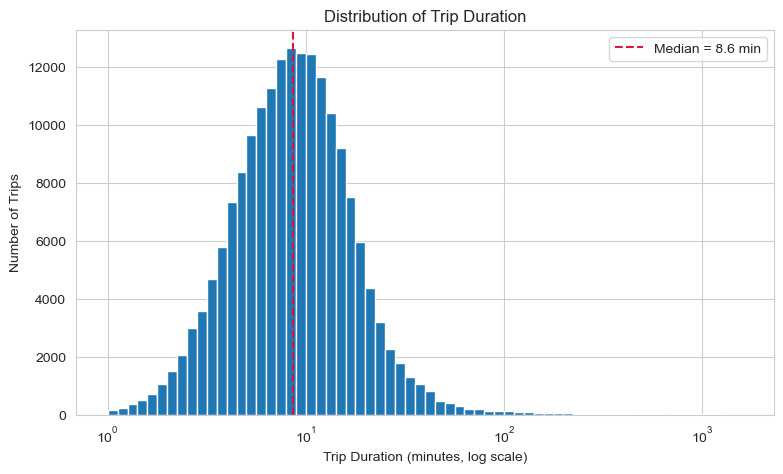

In [8]:
# duration_min is heavily right-skewed (a small number of very long trips), so a
# log-scaled x-axis with log-spaced bins gives a much more readable distribution
# than a linear-scale histogram would.
bins = 10 ** np.arange(0, np.log10(df['duration_min'].max()) + 0.05, 0.05)
median_duration = df['duration_min'].median()

plt.figure(figsize=(9, 5))
plt.hist(data=df, x='duration_min', bins=bins)
plt.xscale('log')
# annotate the median so the skew/central tendency is easy to read off the chart
plt.axvline(median_duration, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Median = {median_duration:.1f} min')
label_plot('Distribution of Trip Duration', 'Trip Duration (minutes, log scale)', 'Number of Trips')
plt.legend()


**Observations:** the distribution is unimodal on the log scale and strongly right-skewed on the linear scale: the median trip is about 8.6 minutes and 75% of trips are 13.3 minutes or shorter, but the longest trip lasted almost 24 hours. Fewer than 0.5% of trips last more than 100 minutes. Because of this skew, a log-scaled x-axis was needed to see the shape of the bulk of the distribution instead of a single spike near zero with a long invisible tail.

### How many rides come from Subscribers vs. Customers?

user_type
Subscriber    89.167557
Customer      10.832443
Name: proportion, dtype: float64

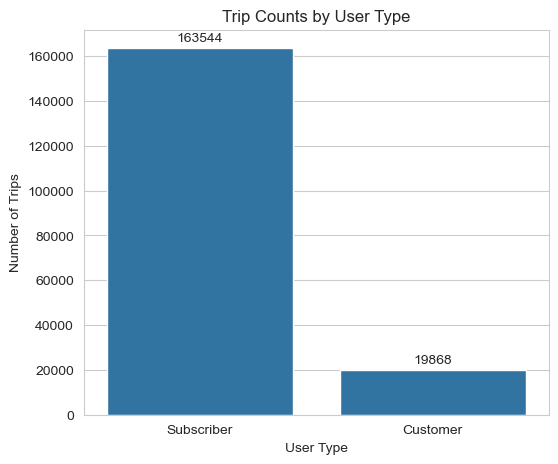

In [9]:
plt.figure(figsize=(6, 5))
order = df['user_type'].value_counts().index
ax = sns.countplot(data=df, x='user_type', order=order, color=sns.color_palette()[0])
label_plot('Trip Counts by User Type', 'User Type', 'Number of Trips')
annotate_bar_counts(ax, fontsize=10, padding=3)


df['user_type'].value_counts(normalize=True) * 100

**Observations:** the large majority of trips, 163,544 (89.2%), are taken by Subscribers, while only 19,868 (10.8%) are taken by Customers. This imbalance is important context for the rest of the analysis; any pattern in the overall data is likely to be driven mostly by Subscriber behavior.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> Trip duration is extremely right-skewed, so I plotted it on a log scale to be able to see the shape of the bulk of the distribution rather than a single tall bar near zero. A very small number of extreme outliers (trips lasting many hours) are visible in the tail; these were kept in the data since they are still plausible (a bike simply left docked-out for a long time) but are downweighted visually by the log scale.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> The `age` field derived from `member_birth_year` had a maximum of 141, an obviously incorrect value. I did not delete these rows (their other fields are still valid), but I restrict/clip the axis range whenever age is plotted so the small number of bad values don't compress the view of the realistic 18-80 age range.

## Bivariate Exploration

Next I look at relationships between pairs of variables, building on `duration_min`, `user_type`, and the time-based features introduced above.

### Does trip duration relate to rider age?

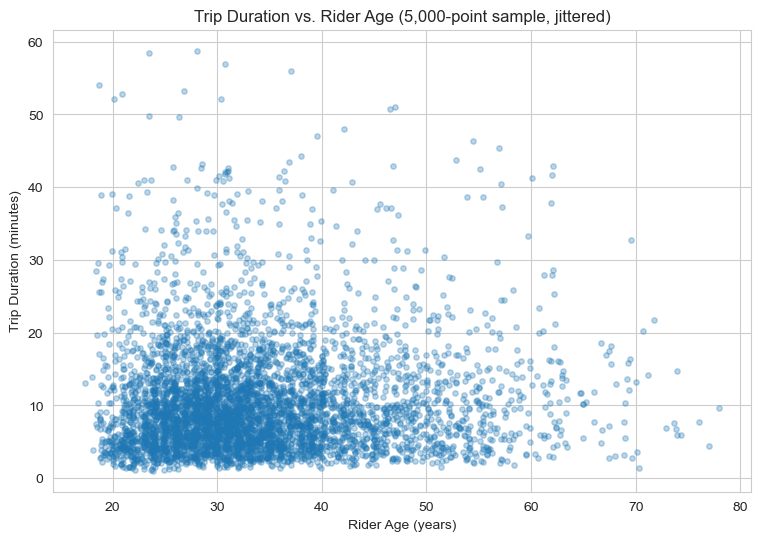

In [10]:
# restrict to plausible ages (<=80) and typical-length trips (<=60 min) so the
# handful of bad ages / extreme-duration outliers don't stretch the axes
plot_df = df[(df['age'] <= 80) & (df['duration_min'] <= 60)]

# with 175k+ points, even a filtered scatter plot is heavily overplotted, and
# age is recorded as a whole number (discrete), which causes points to stack
# in vertical strips. sample_and_jitter() takes a random sample of the data so
# individual points stay distinguishable, and adds a small amount of random
# jitter to age so points no longer stack exactly on top of each other.
sample_df = sample_and_jitter(plot_df, x_col='age', n=5000)

plt.figure(figsize=(9, 6))
plt.scatter(data=sample_df, x='age_jittered', y='duration_min', alpha=0.3, s=15)
label_plot('Trip Duration vs. Rider Age (5,000-point sample, jittered)',
           'Rider Age (years)', 'Trip Duration (minutes)')


**Observations:** a 5,000-point random sample with jitter on the discrete `age` values removes the overplotting/vertical-stacking that made the full-data version hard to read, while still being representative of the overall pattern. There is no strong linear relationship between age and duration — riders of all ages mostly take short trips, with a similar spread of longer trips at every age. There's a very slight tendency for the heaviest concentration of points to sit at lower durations among older riders, but the effect is small.

### Do Subscribers and Customers take trips of different lengths?

,median,mean
user_type,,
Customer,13.200000,23.874417
Subscriber,8.166667,10.671061


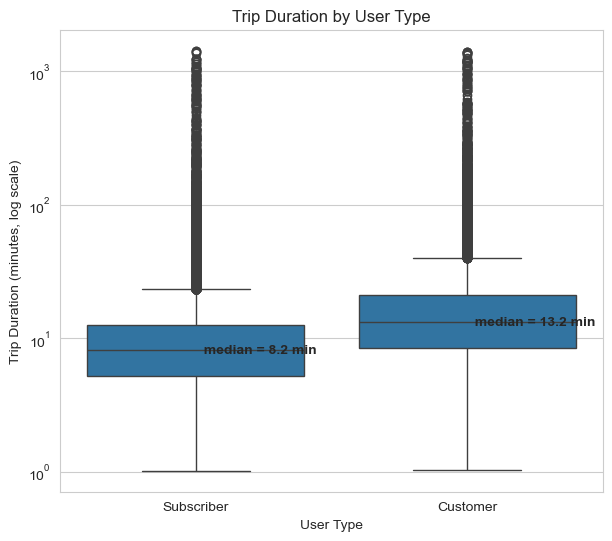

In [11]:
medians = df.groupby('user_type')['duration_min'].median()
order = df['user_type'].value_counts().index

plt.figure(figsize=(7, 6))
sns.boxplot(data=df, x='user_type', y='duration_min', order=order, color=sns.color_palette()[0])
plt.yscale('log')
label_plot('Trip Duration by User Type', 'User Type', 'Trip Duration (minutes, log scale)')

# annotate each box with its exact median value, since the log scale makes it
# hard to read the precise number directly off the axis
annotate_group_medians(medians, order)


df.groupby('user_type')['duration_min'].agg(['median', 'mean'])

**Observations:** Customers take noticeably longer trips than Subscribers: median duration is 13.2 minutes for Customers vs. 8.2 minutes for Subscribers, and the gap is even larger for the mean (23.9 vs. 10.7 minutes) because Customers also have a heavier tail of very long trips. This supports the idea that Subscribers use the system for quick, efficient point-to-point trips (likely commuting) while Customers are more likely to be tourists/leisure riders who keep the bike longer.

### When during the week and day do trips happen?

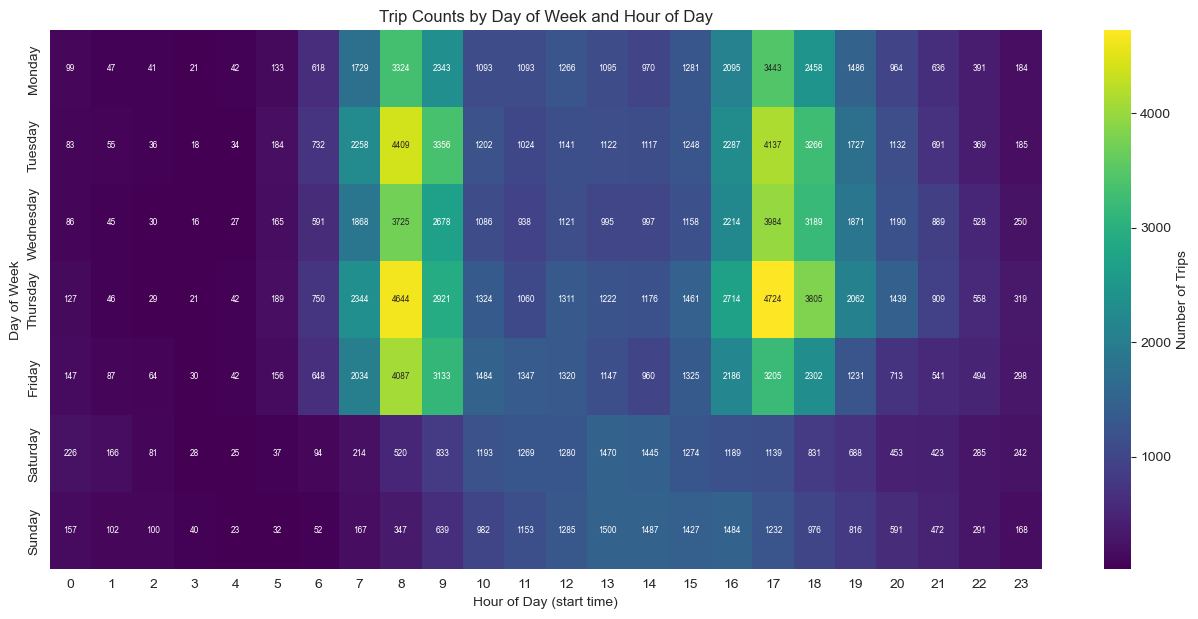

In [12]:
# pivot to a day-of-week x hour-of-day grid of trip counts
heat_data = df.pivot_table(index='day_of_week', columns='hour', values='duration_sec', aggfunc='count',observed=False)

plt.figure(figsize=(16, 7))
# annotate each cell with its trip count so exact values are readable, not just color
sns.heatmap(heat_data, cmap='viridis', annot=True, fmt='d', annot_kws={'size': 6},
            cbar_kws={'label': 'Number of Trips'})
label_plot('Trip Counts by Day of Week and Hour of Day', 'Hour of Day (start time)', 'Day of Week')


**Observations:** on weekdays (Monday-Friday) there are two clear peaks, around 8am and 5pm, consistent with a commute pattern. On Saturday and Sunday, usage is lower overall and more evenly spread across the late morning and afternoon, with no sharp commute peaks. This is a strong hint that the overall trip pattern is dominated by weekday commuting.

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> Trip duration varies much more with `user_type` than with `age`: Customers ride noticeably longer than Subscribers, while age on its own shows little relationship with duration. Looking at time of day and day of week together revealed a clear weekday commute pattern (peaks at 8am and 5pm) that is largely absent on weekends.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> The weekday commute-peak pattern itself was an interesting relationship between `day_of_week` and `hour`, independent of `user_type` — it suggests the time-of-day feature alone can serve as a rough proxy for trip purpose (commute vs. leisure), which I explore further below.

## Multivariate Exploration

Finally, I bring `user_type` together with the time-of-week patterns identified above to see whether the weekday commute pattern is really a Subscriber phenomenon.

### Does the duration distribution differ by user type *and* weekday/weekend?

Text(0.5, 1.03, 'Trip Duration Distribution by User Type and Day Type')

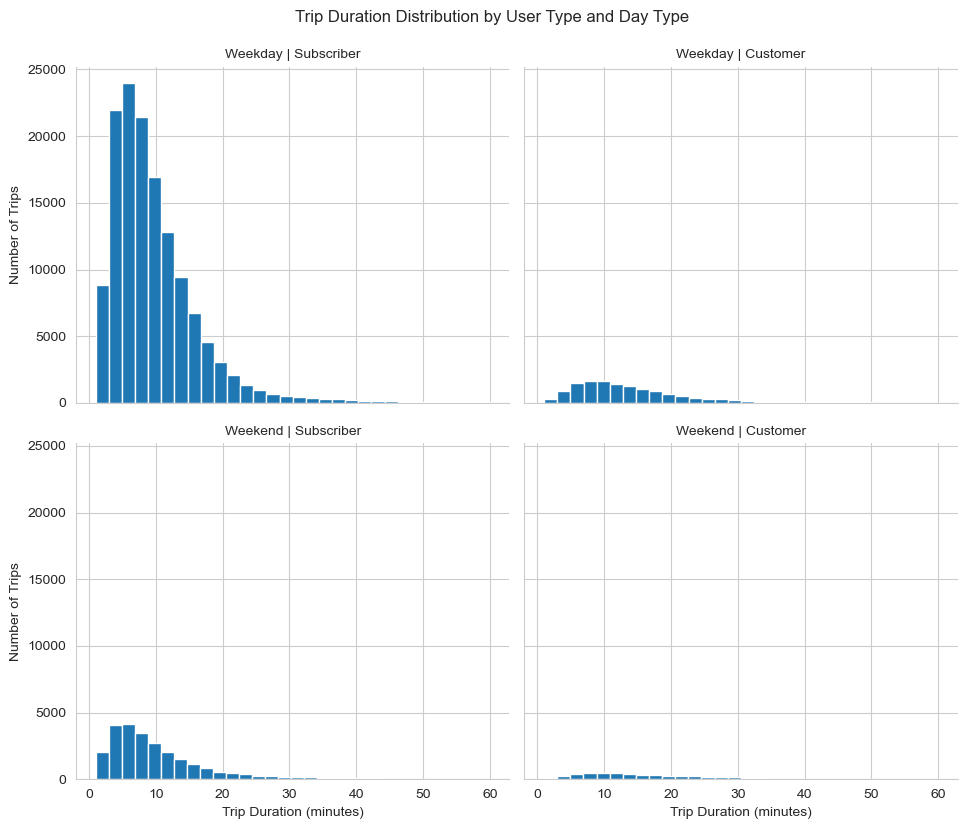

In [13]:
# facet plot: duration distribution split by user_type (columns) and weekday/weekend (rows)
plot_df = df[df['duration_min'] <= 60].copy()
plot_df['day_type'] = plot_df['is_weekend'].map({False: 'Weekday', True: 'Weekend'})

g = sns.FacetGrid(plot_df, col='user_type', row='day_type', height=4, aspect=1.2)
g.map(plt.hist, 'duration_min', bins=30, color=sns.color_palette()[0])
g.set_axis_labels('Trip Duration (minutes)', 'Number of Trips')
g.set_titles(col_template='{col_name}', row_template='{row_name}')
g.fig.suptitle('Trip Duration Distribution by User Type and Day Type', y=1.03)


**Observations:** Subscriber trip-duration distributions look almost identical on weekdays and weekends: a tight peak around 5-10 minutes. Customers, in contrast, shift toward longer durations on weekends, with a visibly wider and flatter distribution than on weekdays. This supports the commuter-vs-leisure story: Subscriber behavior is stable regardless of day type, while Customer behavior shifts toward more relaxed/leisure trips on weekends.

### Do duration, age, and time-of-day jointly separate the two user types?

The clustered bar chart used earlier only really encodes two variables (day of week and user type), so it's a bivariate view rather than a true multivariate one. To look at several variables together, I use a **plot matrix**: pairwise scatter/density plots of `duration_min`, `age`, and `hour`, colored by `user_type`.

Text(0.5, 1.02, 'Plot Matrix: Duration, Age, and Hour of Day by User Type')

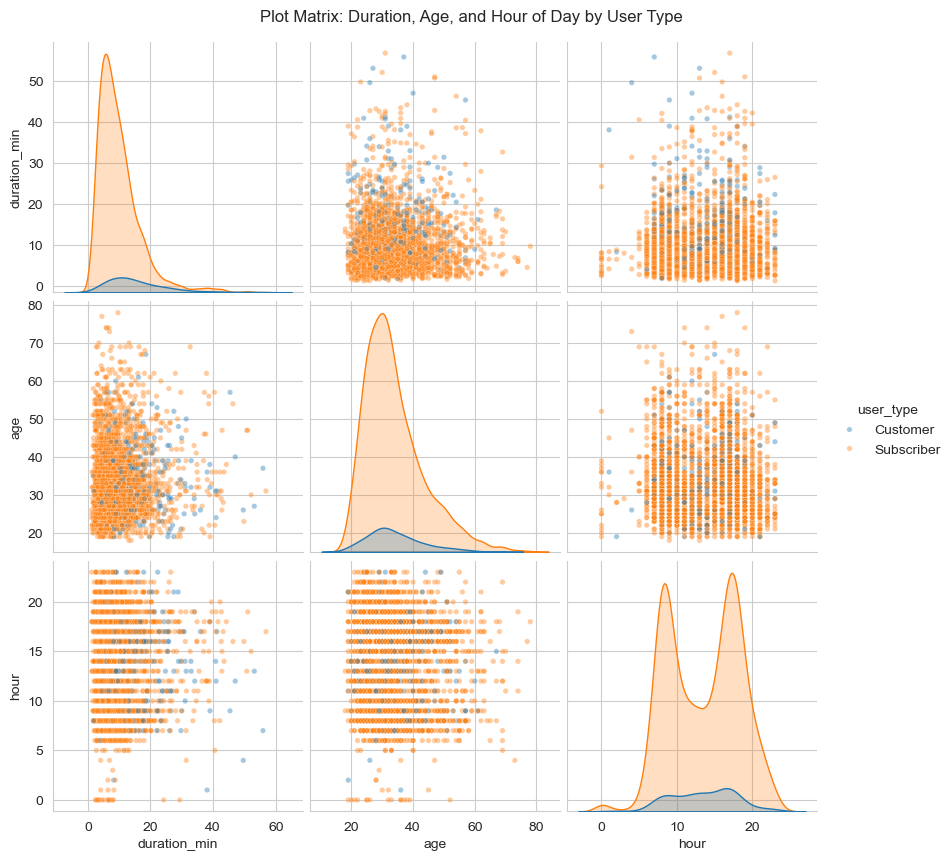

In [14]:
# restrict to plausible values and take a random sample; a pairplot draws every
# pairwise combination of variables, so plotting all 175k+ rows would be both
# very slow and heavily overplotted
matrix_df = df[(df['age'] <= 80) & (df['duration_min'] <= 60)]
matrix_sample = matrix_df.sample(n=3000, random_state=42)

g = sns.pairplot(matrix_sample, vars=['duration_min', 'age', 'hour'], hue='user_type',
                  plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde', height=2.8)
g.fig.suptitle('Plot Matrix: Duration, Age, and Hour of Day by User Type', y=1.02)


**Observations:** the diagonal KDEs echo earlier findings — Customer (orange) duration is shifted toward longer values than Subscriber (blue), while the two user types' age distributions largely overlap. The `hour` vs. `duration_min` panel shows Subscriber trips staying short across all hours, while Customer trips are both longer and more spread out throughout the day, with no strong commute-hour concentration. No pair of variables shows a strong joint linear relationship; the clearest separation between user types still comes from `duration_min` alone, with age and hour adding comparatively little extra separation on their own.

In [15]:
# how does the weekday/weekend split of trips differ between the two user types?
df.groupby('user_type')['is_weekend'].mean() * 100

user_type
Customer      28.362190
Subscriber    15.465563
Name: is_weekend, dtype: float64

**Observations:** only 15.5% of Subscriber trips happen on a weekend, vs. 28.4% of Customer trips — roughly 1.8x higher. Together with the duration, time-of-day, and plot-matrix findings, this consistently paints Subscribers as weekday commuters and Customers as a mix of weekday and weekend, more leisure-oriented, users.

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> `user_type` and `is_weekend`/`day_of_week` reinforced each other: Subscribers are consistently short-trip, weekday-heavy users, while Customers are more variable in both duration and timing, and lean more (relatively) toward weekends. Each new variable added supported the same underlying commuter-vs-leisure story rather than contradicting it.

### Were there any interesting or surprising interactions between features?

> The facet plot showed that it's specifically the *Customer* duration distribution that shifts between weekday and weekend, while the *Subscriber* distribution barely moves — the interaction between `user_type` and `day_type` is not symmetric, which wasn't obvious from either variable's univariate/bivariate patterns alone.

## Conclusions

Summary of the main findings from this exploration:

- Trip duration is heavily right-skewed; the typical (median) trip is about 8.6 minutes, and 99% of trips last under an hour.
- Subscribers account for the large majority of trips (89.2%) and take much shorter trips than Customers (median 8.2 vs. 13.2 minutes).
- Weekday usage shows a clear two-peak commute pattern (around 8am and 5pm); this pattern is much weaker on weekends.
- Only 15.5% of Subscriber trips happen on a weekend, compared to 28.4% of Customer trips.
- Customer trip-duration distributions shift toward longer trips on weekends, while Subscriber trip-duration distributions stay essentially the same regardless of day type.
- Together, these findings support a clear behavioral split: **Subscribers primarily use the system for short, weekday commute trips, while Customers use it more for longer, leisure-oriented trips that are less tied to the work week.**